##Credit Card Fraud detection

##Context
It is important that banks and credit-card companies are able to recognize fraudulent credit card transactions so that customers are not charged for items that they did not purchase.


#Abou the Dataset
The dataset contains credit card transactions made by European cardholders during September 2013. It represents transactions recorded over a two-day period and consists of 116,705 transactions, including 244 fraudulent transactions. The dataset is highly imbalanced, with fraudulent transactions accounting for approximately 0.21% of the total transactions.

Due to confidentiality and privacy concerns, the original feature information and additional details about the transactions are not disclosed. The dataset contains 30 features, including V1 through V28, which represent principal components obtained through Principal Component Analysis (PCA). The original transaction characteristics have been transformed into these anonymized numerical components to preserve confidentiality while retaining meaningful patterns within the data.

The Time feature represents the number of seconds elapsed between a transaction and the first transaction recorded in the dataset, while Amount denotes the monetary value of each transaction. The Class feature serves as the target variable, where a value of 1 indicates a fraudulent transaction and 0 represents a legitimate transaction.

Given the significant class imbalance, this dataset provides a suitable foundation for developing and evaluating fraud detection and anomaly classification models, where accurately identifying the minority fraud class is particularly important.

In [ ]:
import numpy as np
import pandas as pd
import sklearn
import scipy
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report,accuracy_score
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from pylab import rcParams
rcParams['figure.figsize'] = 14, 8
RANDOM_SEED = 42
LABELS = ["Normal", "Fraud"]

In [ ]:
data = pd.read_csv('/content/compressed_data (2) (1).csv',sep=',')
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116705 entries, 0 to 116704
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    116705 non-null  int64  
 1   V1      116705 non-null  float64
 2   V2      116705 non-null  float64
 3   V3      116705 non-null  float64
 4   V4      116705 non-null  float64
 5   V5      116705 non-null  float64
 6   V6      116705 non-null  float64
 7   V7      116705 non-null  float64
 8   V8      116705 non-null  float64
 9   V9      116705 non-null  float64
 10  V10     116705 non-null  float64
 11  V11     116705 non-null  float64
 12  V12     116705 non-null  float64
 13  V13     116705 non-null  float64
 14  V14     116705 non-null  float64
 15  V15     116705 non-null  float64
 16  V16     116705 non-null  float64
 17  V17     116705 non-null  float64
 18  V18     116705 non-null  float64
 19  V19     116705 non-null  float64
 20  V20     116705 non-null  float64
 21  V21     11

##EDA

In [ ]:
data.isnull().values.any()

np.False_

/tmp/ipykernel_4948/2812369284.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  count_classes = pd.value_counts(data['Class'], sort = True)


Text(0, 0.5, 'Frequency')

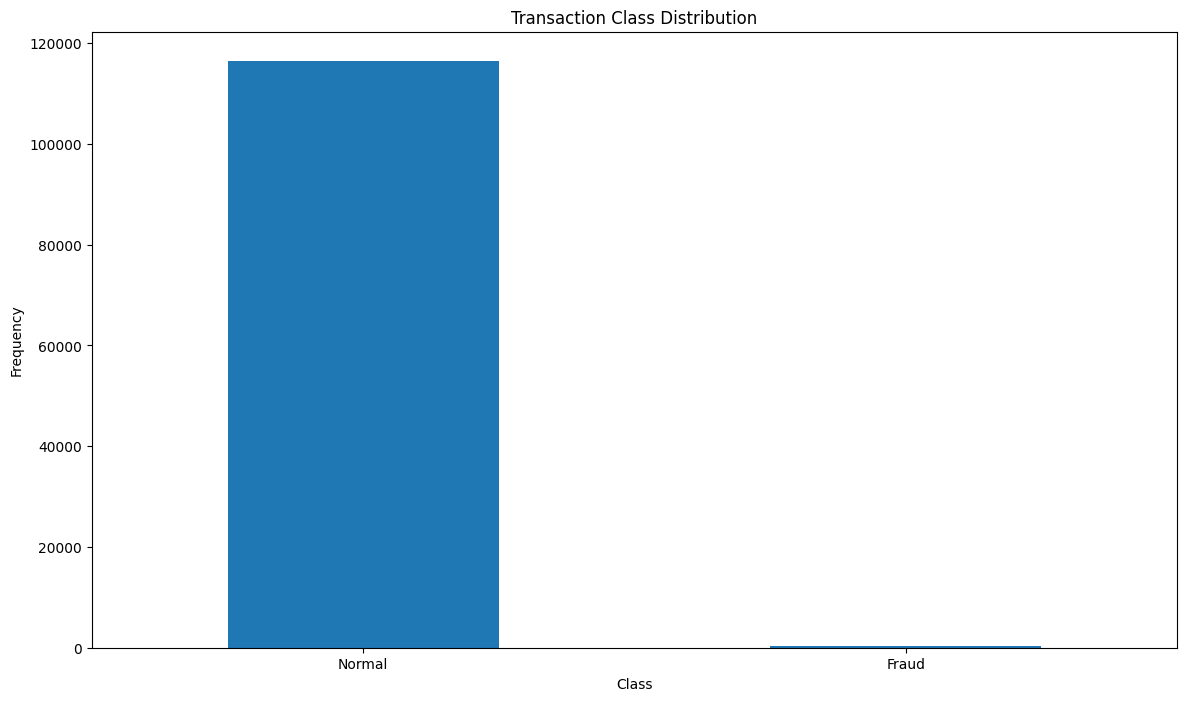

In [ ]:
count_classes = pd.value_counts(data['Class'], sort = True)

count_classes.plot(kind = 'bar', rot=0)

plt.title("Transaction Class Distribution")

plt.xticks(range(2), LABELS)

plt.xlabel("Class")

plt.ylabel("Frequency")

In [ ]:
## Get the Fraud and the normal dataset

fraud = data[data['Class']==1]

normal = data[data['Class']==0]

In [ ]:
print(fraud.shape,normal.shape)

(244, 31) (116461, 31)


In [ ]:
normal.Amount.describe()

,Amount
count,116461.000000
mean,94.634111
std,256.489884
min,0.000000
25%,6.950000
50%,25.000000
75%,85.000000
max,19656.530000


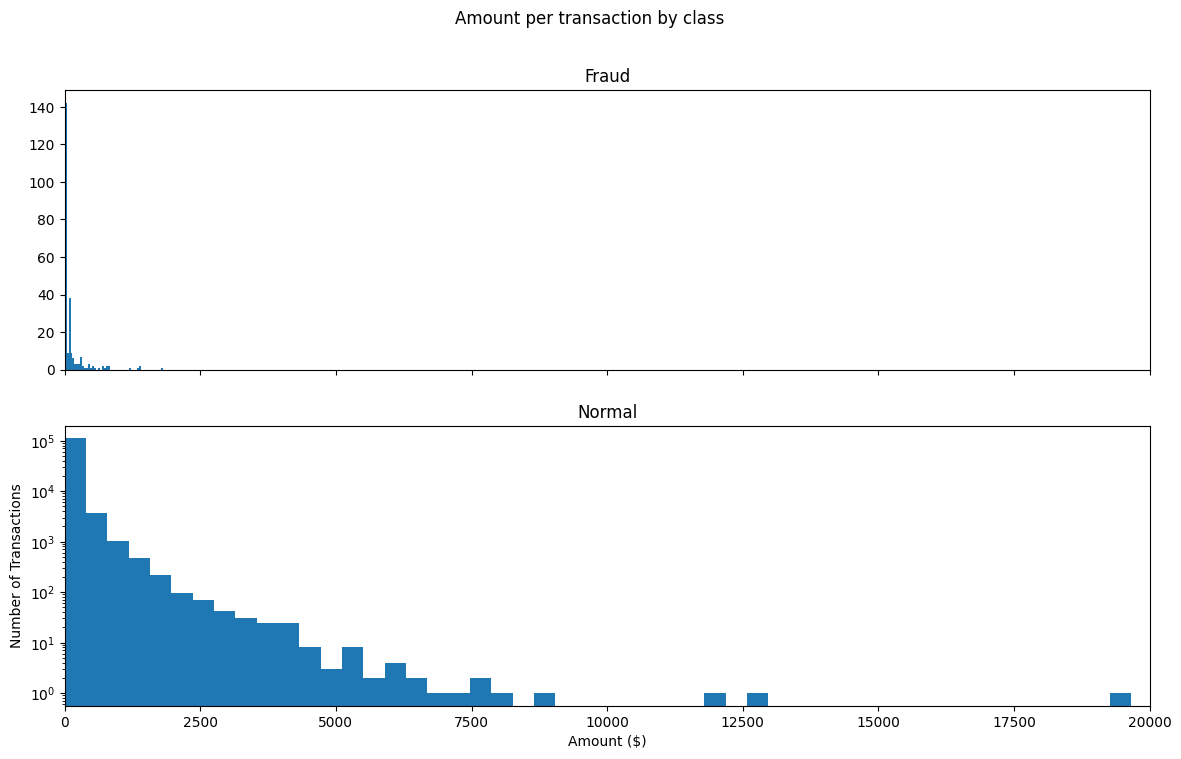

In [ ]:
f, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
f.suptitle('Amount per transaction by class')
bins = 50
ax1.hist(fraud.Amount, bins = bins)
ax1.set_title('Fraud')
ax2.hist(normal.Amount, bins = bins)
ax2.set_title('Normal')
plt.xlabel('Amount ($)')
plt.ylabel('Number of Transactions')
plt.xlim((0, 20000))
plt.yscale('log')
plt.show();

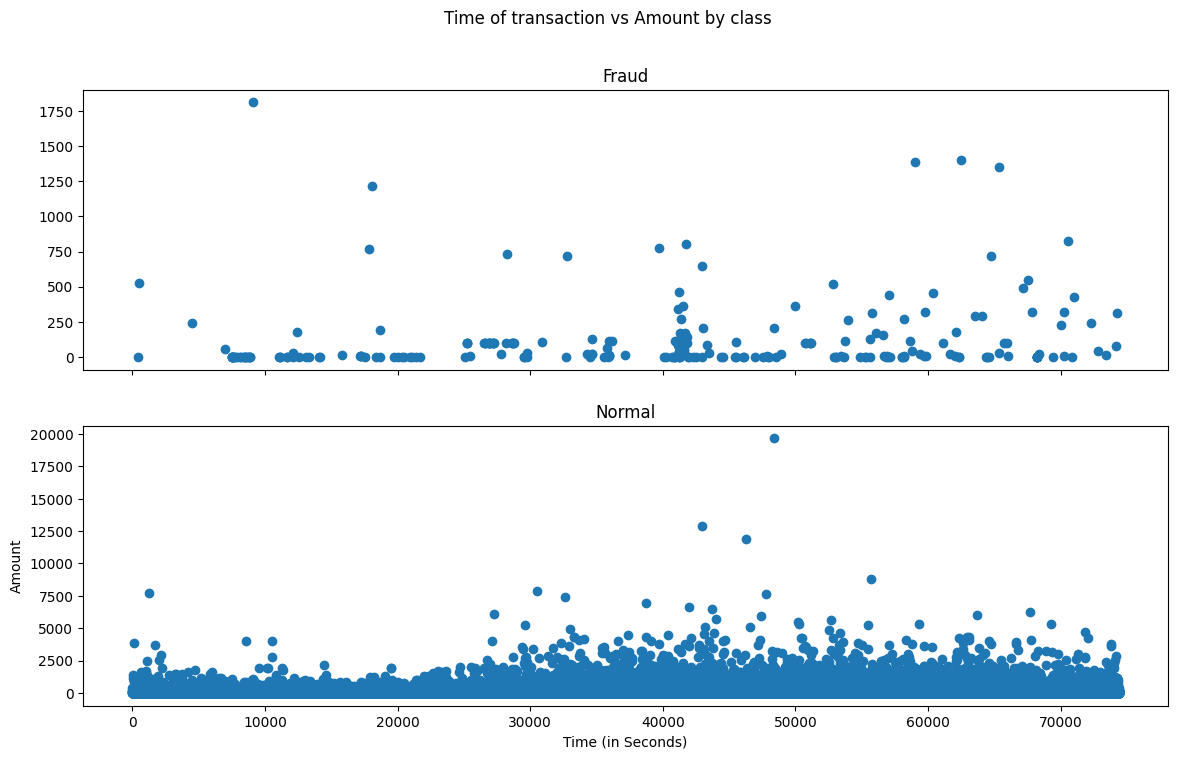

In [ ]:
# We Will check Do fraudulent transactions occur more often during certain time frame ? Let us find out with a visual representation.

f, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
f.suptitle('Time of transaction vs Amount by class')
ax1.scatter(fraud.Time, fraud.Amount)
ax1.set_title('Fraud')
ax2.scatter(normal.Time, normal.Amount)
ax2.set_title('Normal')
plt.xlabel('Time (in Seconds)')
plt.ylabel('Amount')
plt.show()

In [ ]:
## Take some sample of the data

data1= data.sample(frac = 0.1,random_state=1)

data1.shape

(11670, 31)

In [ ]:
data.shape

(116705, 31)

In [ ]:
#Determine the number of fraud and valid transactions in the dataset

Fraud = data1[data1['Class']==1]

Valid = data1[data1['Class']==0]

outlier_fraction = len(Fraud)/float(len(Valid))

In [ ]:
print(outlier_fraction)

print("Fraud Cases : {}".format(len(Fraud)))

print("Valid Cases : {}".format(len(Valid)))

0.0014588517978203037
Fraud Cases : 17
Valid Cases : 11653


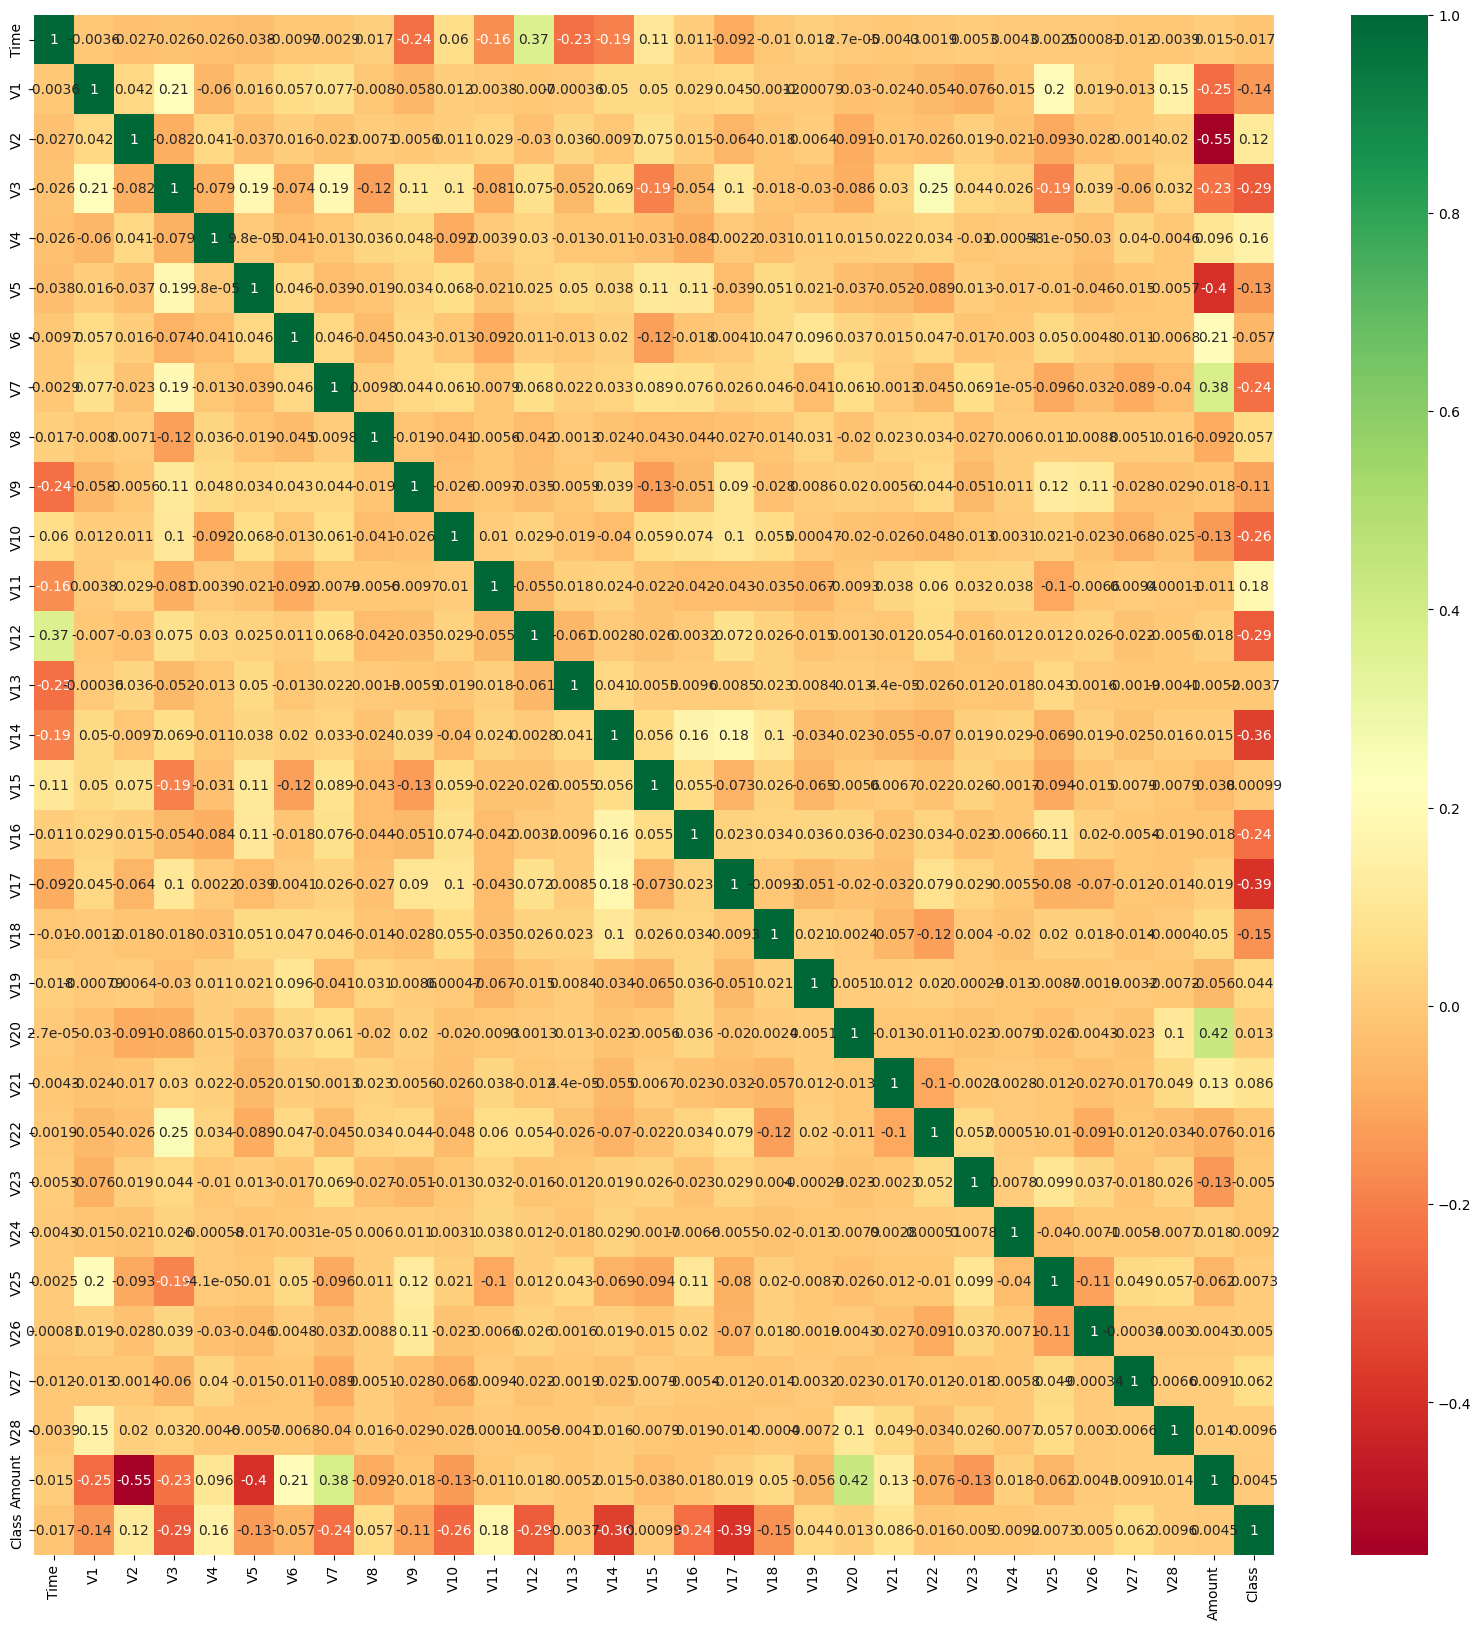

In [ ]:
## Correlation
import seaborn as sns
#get correlations of each features in dataset
corrmat = data1.corr()
top_corr_features = corrmat.index
plt.figure(figsize=(20,20))
#plot heat map
g=sns.heatmap(data[top_corr_features].corr(),annot=True,cmap="RdYlGn")

In [ ]:
#Create independent and Dependent Features
columns = data1.columns.tolist()
# Filter the columns to remove data we do not want
columns = [c for c in columns if c not in ["Class"]]
# Store the variable we are predicting
target = "Class"
# Define a random state
state = np.random.RandomState(42)
X = data1[columns]
Y = data1[target]
X_outliers = state.uniform(low=0, high=1, size=(X.shape[0], X.shape[1]))
# Print the shapes of X & Y
print(X.shape)
print(Y.shape)

(11670, 30)
(11670,)


#Model Selection (Isolation Forest ,Local Outlier Factor ,SVM ) and Comparison :

In [ ]:
##Define the outlier detection methods

classifiers = {
    "Isolation Forest":IsolationForest(n_estimators=100, max_samples=len(X),
                                       contamination=outlier_fraction,random_state=state, verbose=0),
    "Local Outlier Factor":LocalOutlierFactor(n_neighbors=20, algorithm='auto',
                                              leaf_size=30, metric='minkowski',
                                              p=2, metric_params=None, contamination=outlier_fraction),
    "Support Vector Machine":OneClassSVM(kernel='rbf', degree=3, gamma=0.1,nu=0.05,
                                         max_iter=-1)

}

In [ ]:
type(classifiers)

dict

In [ ]:
n_outliers = len(Fraud)
for i, (clf_name,clf) in enumerate(classifiers.items()):
    #Fit the data and tag outliers
    if clf_name == "Local Outlier Factor":
        y_pred = clf.fit_predict(X)
        scores_prediction = clf.negative_outlier_factor_
    elif clf_name == "Support Vector Machine":
        clf.fit(X)
        y_pred = clf.predict(X)
    else:
        clf.fit(X)
        scores_prediction = clf.decision_function(X)
        y_pred = clf.predict(X)
    #Reshape the prediction values to 0 for Valid transactions , 1 for Fraud transactions
    y_pred[y_pred == 1] = 0
    y_pred[y_pred == -1] = 1
    n_errors = (y_pred != Y).sum()
    # Run Classification Metrics
    print("{}: {}".format(clf_name,n_errors))
    print("Accuracy Score :")
    print(accuracy_score(Y,y_pred))
    print("Classification Report :")
    print(classification_report(Y,y_pred))

Isolation Forest: 21
Accuracy Score :
0.9982005141388175
Classification Report :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11653
           1       0.39      0.41      0.40        17

    accuracy                           1.00     11670
   macro avg       0.69      0.71      0.70     11670
weighted avg       1.00      1.00      1.00     11670

Local Outlier Factor: 35
Accuracy Score :
0.9970008568980291
Classification Report :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11653
           1       0.00      0.00      0.00        17

    accuracy                           1.00     11670
   macro avg       0.50      0.50      0.50     11670
weighted avg       1.00      1.00      1.00     11670

Support Vector Machine: 4211
Accuracy Score :
0.6391602399314481
Classification Report :
              precision    recall  f1-score   support

           0       1.00      0.64   

###Observations :
Isolation Forest performed the best overall among the three anomaly detection models, producing 21 misclassified transactions, compared with 35 errors for Local Outlier Factor (LOF) and 4,211 errors for Support Vector Machine (SVM).

Isolation Forest achieved an overall accuracy of 99.82%, outperforming LOF with 99.70% and SVM with 63.92%. However, because the dataset is highly imbalanced, overall accuracy alone is not sufficient to evaluate fraud detection performance.

For the fraud class (Class = 1), Isolation Forest achieved a precision of 39% and recall of 41%, with an F1-score of 40%. This indicates that the model was able to identify approximately 41% of the actual fraudulent transactions in the evaluated dataset.
LOF achieved 0% precision and 0% recall for the fraud class, indicating that it was unable to effectively identify the fraudulent transactions in this evaluation, despite achieving a high overall accuracy of 99.70%.

SVM achieved a recall of 29% for the fraud class, but its fraud precision was 0%, along with a significantly lower overall accuracy of 63.92%. It also generated a considerably larger number of classification errors (4,211) compared with Isolation Forest and LOF.

Therefore, considering both overall performance and the ability to identify the minority fraud class, Isolation Forest was the most effective model among the three. Its 41% fraud recall was substantially higher than LOF's 0% and SVM's 29%.

The results also highlight the challenge posed by the highly imbalanced nature of the dataset. Although Isolation Forest achieved 99.82% accuracy, its fraud recall of 41% shows that there is still considerable scope for improving the detection of fraudulent transactions.




# Improvements
The model performance could potentially be improved by increasing the training/sample size, tuning the anomaly-detection parameters, experimenting with more sophisticated anomaly-detection techniques, or applying advanced machine-learning/deep-learning approaches. Such improvements may help increase fraud detection capability, although more complex approaches can require additional computational resources.